In [1]:
#implement a simple CNN for image classification. Write a python program to build a CNN for the MNIST Dataset, including convolution and pooling layers

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


In [3]:
mnist=tf.keras.datasets.mnist
(X_train, Y_train), (X_test, Y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
X_train, X_test= X_train/255.0, X_test/255.0

In [6]:
X_train=X_train.reshape(-1, 28, 28, 1)
X_test=X_test.reshape(-1,28,28,1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 33ms/step - accuracy: 0.7459 - loss: 0.7426 - val_accuracy: 0.9180 - val_loss: 0.2718
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 31ms/step - accuracy: 0.9279 - loss: 0.2341 - val_accuracy: 0.9441 - val_loss: 0.1766
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9532 - loss: 0.1537 - val_accuracy: 0.9662 - val_loss: 0.1122
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9643 - loss: 0.1158 - val_accuracy: 0.9716 - val_loss: 0.0975
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9696 - loss: 0.0962 - val_accuracy: 0.9757 - val_loss: 0.0744
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9757 - loss: 0.0744
Test Accuracy: 0.9757
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


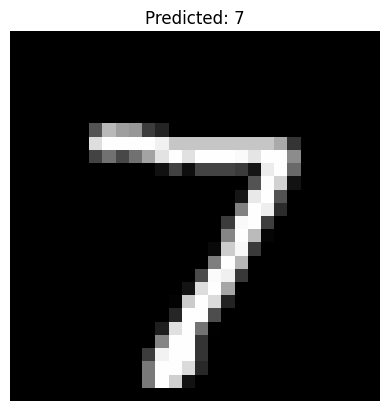

In [8]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')

])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    Y_train,
    epochs=5,
    validation_data=(X_test, Y_test)
)

test_loss, test_acc = model.evaluate(X_test, Y_test)

print(f"Test Accuracy: {test_acc:.4f}")

predictions = model.predict(X_test[:5])

plt.imshow(X_test[0].reshape(28,28), cmap='gray')

plt.title(f"Predicted: {np.argmax(predictions[0])}")

plt.axis('off')

plt.show()